In [20]:
import urllib.request
import tarfile

url = "http://download.tensorflow.org/example_images/flower_photos.tgz"
urllib.request.urlretrieve(url, "flower_photos.tgz")

with tarfile.open("flower_photos.tgz") as tar:
    tar.extractall(".")

print("Listo")

KeyboardInterrupt: 

#Preprocesamiento#

Cargamos las imágenes desde la carpeta usando image_dataset_from_directory, que automáticamente asigna etiquetas según el nombre de cada subcarpeta. Dividimos 80% entrenamiento y 20% validación. Redimensionamos todas las imágenes a 128x128 píxeles para que la red reciba entradas uniformes. Normalizamos dividiendo entre 255 para llevar los valores de píxel al rango [0,1], lo que ayuda a que el modelo converja más rápido.

In [ ]:
import tensorflow as tf
import pathlib

data_dir = pathlib.Path("flower_photos")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Clases:", class_names)

# Normalizar píxeles 0-255 → 0-1
normalization = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization(x), y))

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Clases: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


Arquitectura CNN

Definimos una red neuronal convolucional secuencial. Las capas Conv2D detectan patrones visuales (bordes, texturas, formas) en la imagen. Después de cada convolución, MaxPooling2D reduce el tamaño espacial conservando lo más relevante. Al final, Flatten convierte la salida en un vector, Dense(128) aprende combinaciones de esos patrones, Dropout(0.3) apaga aleatoriamente el 30% de neuronas para evitar sobreajuste, y la última Dense(5, softmax) produce una probabilidad por cada clase de flor.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento

Llamamos a model.fit() pasándole los datos de entrenamiento y validación. En cada epoch el modelo ve todos los ejemplos, calcula el error (loss), y ajusta sus pesos mediante backpropagation con el optimizador Adam. La validación nos permite ver si el modelo generaliza o está memorizando los datos de entrenamiento.

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.3937 - loss: 1.3488 - val_accuracy: 0.5218 - val_loss: 1.1404
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.5640 - loss: 1.0692 - val_accuracy: 0.6335 - val_loss: 0.9756
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6349 - loss: 0.9248 - val_accuracy: 0.6662 - val_loss: 0.8710
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.6948 - loss: 0.8012 - val_accuracy: 0.6921 - val_loss: 0.8534
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.7435 - loss: 0.6501 - val_accuracy: 0.7098 - val_loss: 0.8259
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.7936 - loss: 0.5485 - val_accuracy: 0.7044 - val_loss: 0.8518
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8351 - loss: 0.4340 - val_accuracy: 0.6921 - val_loss: 0.9246
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8815 - loss: 0.3302 - val_accuracy: 0.6907 - 

In [ ]:
#EL MODELO QUE SOBRE AJUSTADO POR QUE TUVE 97% DE TRAIN ACCURACY PERO SU VAL ACCURACY FUE DE 66 UNA DIFERENCIA MUY GRANDE, SE DEBE DE AJUSTAR.

Data Augmentation + Reentrenamiento

El modelo anterior aprendió demasiado bien los datos de entrenamiento pero falló al ver imágenes nuevas, eso se llama sobreajuste. Para combatirlo, aplicamos data augmentation, que es una técnica que genera variaciones artificiales de cada imagen durante el entrenamiento: la voltea horizontalmente, la rota un poco y le hace zoom. Así el modelo ve la misma flor desde distintos ángulos y aprende características más generales en lugar de memorizar las imágenes exactas.


También aumentamos el Dropout de 0.3 a 0.5, lo que significa que ahora apagamos el 50% de las neuronas aleatoriamente en cada paso, forzando a la red a no depender de neuronas específicas y volviéndola más robusta.


Entrenamos por 20 epochs en lugar de 15 porque el augmentation hace el problema más difícil y el modelo necesita más iteraciones para aprender. El objetivo es que la accuracy de validación se acerque más a la de entrenamiento, señal de que el modelo generaliza bien a imágenes que nunca ha visto.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

model2 = keras.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.3958 - loss: 1.3916 - val_accuracy: 0.5286 - val_loss: 1.1350
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.5249 - loss: 1.1413 - val_accuracy: 0.5736 - val_loss: 1.0486
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.5821 - loss: 1.0516 - val_accuracy: 0.5777 - val_loss: 1.0520
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.6066 - loss: 0.9965 - val_accuracy: 0.6322 - val_loss: 0.9253
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.6236 - loss: 0.9546 - val_accuracy: 0.6689 - val_loss: 0.8831
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6260 - loss: 0.9117 - val_accuracy: 0.6417 - val_loss: 0.9136
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.6754 - loss: 0.8471 - val_accuracy: 0.6417 - val_loss: 0.8970
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.6717 - loss: 0.8530 - val_accuracy: 0.7071 -

In [ ]:
model2.save(r"C:\parcial_ciencia_de_datoss\modelo_flores.keras")
print("Listo")

Listo


In [ ]:
from google.colab import files
files.download("modelo_flores.keras")

FileNotFoundError: Cannot find file: modelo_flores.keras

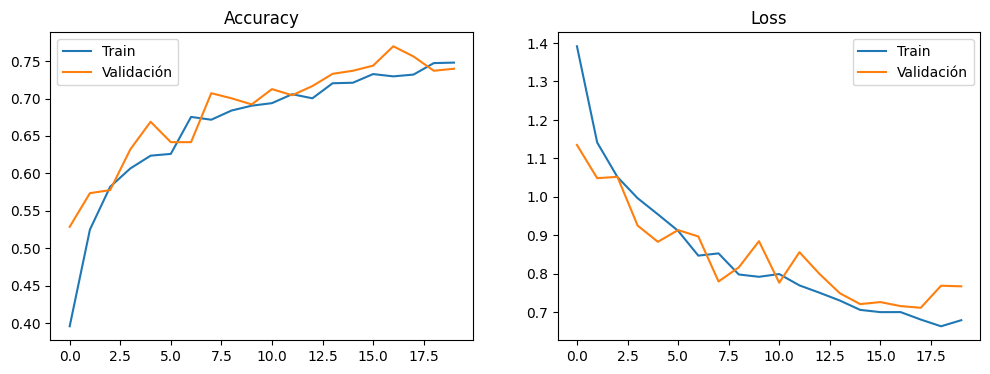

In [ ]:
import matplotlib.pyplot as plt

acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']
loss = history2.history['loss']
val_loss = history2.history['val_loss']
epochs_range = range(20)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train')
plt.plot(epochs_range, val_acc, label='Validación')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train')
plt.plot(epochs_range, val_loss, label='Validación')
plt.title('Loss')
plt.legend()

plt.show()

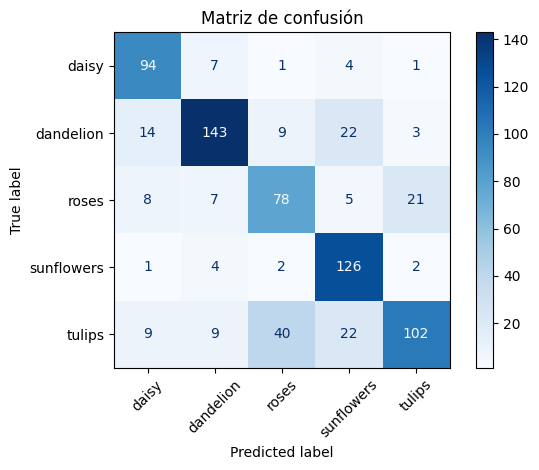

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model2.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()